In [ ]:
Paciente = [1, 2, 3, 4, 5] #colocamos las listas
Dosis = [8, 9, 10, 13, 15]
Respuesta = [5, 4, 4, 6, 8]

In [ ]:
import statistics #importamos la biblioteca statistics para obtener los promedios

In [ ]:
promedio_x = statistics.mean(Dosis) #obtenemos el promedio de x (dosis)
promedio_x

11

In [ ]:
promedio_y = statistics.mean(Respuesta) #obtenemos el promedio de y (respuesta)
promedio_y

5.4

In [ ]:
n = len(Paciente) #definimos la cantidad de datos que tiene la lista
n

5

In [ ]:
cov = 0 #la covarianza empieza de 0
for i in range(n): #empezamos un ciclo for para i en un rango n que son nuestra cantidad de datos en la lista
    cov +=(Dosis[i] - promedio_x) * (Respuesta[i] - promedio_y) / (n-1) #el ciclo para que se vayan sumando los i datos, e ingresamos la formula de la covarianza

print('La covarianza es: ', cov) # imprimimos la covarianza acompañada de un texto

La covarianza es:  4.25


In [ ]:
import pandas as pd #importamos la biblioteca pandas para poder trabajar con dataframes

In [ ]:
ruta = 'https://raw.githubusercontent.com/marinlopabi/Temas_Selectos_PQ_26-I/refs/heads/main/ARCHIVOS/contam2022.csv'
df = pd.read_csv (ruta, sep=',') #cuando no sale bien hay que cambiar el separador ()
df.head()

,Fecha,Centro Ozono,Centro diÛxido de azufre,Centro diÛxido de nitrÛgeno,Centro monÛxido de carbono,Centro PM10
0,2022-01-01,36.916667,6.333333,22.458333,10.208333,106.916667
1,2022-01-02,17.250000,7.750000,15.833333,9.500000,97.875000
2,2022-01-03,24.083333,7.833333,17.875000,5.041667,61.958333
3,2022-01-04,27.583333,27.416667,27.125000,8.250000,91.333333
4,2022-01-05,30.875000,12.833333,25.791667,9.791667,94.000000


In [ ]:
df = df.rename(columns={
    'Centro Ozono' : 'O3',
    'Centro diÛxido de azufre': 'SO2',
    'Centro diÛxido de nitrÛgeno': 'NO2',
    'Centro monÛxido de carbono':'CO',
    'Centro PM10': 'PM10',
 })
df.columns

Index(['O3', 'SO2', 'NO2', 'CO', 'PM10'], dtype='object')

In [ ]:

df = df.set_index("Fecha")
df


,O3,SO2,NO2,CO,PM10
Fecha,,,,,
2022-01-01,36.916667,6.333333,22.458333,10.208333,106.916667
2022-01-02,17.250000,7.750000,15.833333,9.500000,97.875000
2022-01-03,24.083333,7.833333,17.875000,5.041667,61.958333
2022-01-04,27.583333,27.416667,27.125000,8.250000,91.333333
2022-01-05,30.875000,12.833333,25.791667,9.791667,94.000000
...,...,...,...,...,...
2022-12-27,19.041667,5.750000,18.541667,5.583333,39.500000
2022-12-28,17.041667,11.000000,19.125000,8.583333,53.666667
2022-12-29,14.083333,4.750000,16.791667,7.625000,42.416667


**COORRELACION DE SPEARMAN**

In [ ]:
corr_spearman = df.corr(method='spearman')

corr_spearman

,O3,SO2,NO2,CO,PM10
O3,1.000000,0.197253,0.181516,0.051342,0.481537
SO2,0.197253,1.000000,0.416420,0.296297,0.585443
NO2,0.181516,0.416420,1.000000,0.847467,0.643303
CO,0.051342,0.296297,0.847467,1.000000,0.571305
PM10,0.481537,0.585443,0.643303,0.571305,1.000000


Gráfico de Spearman

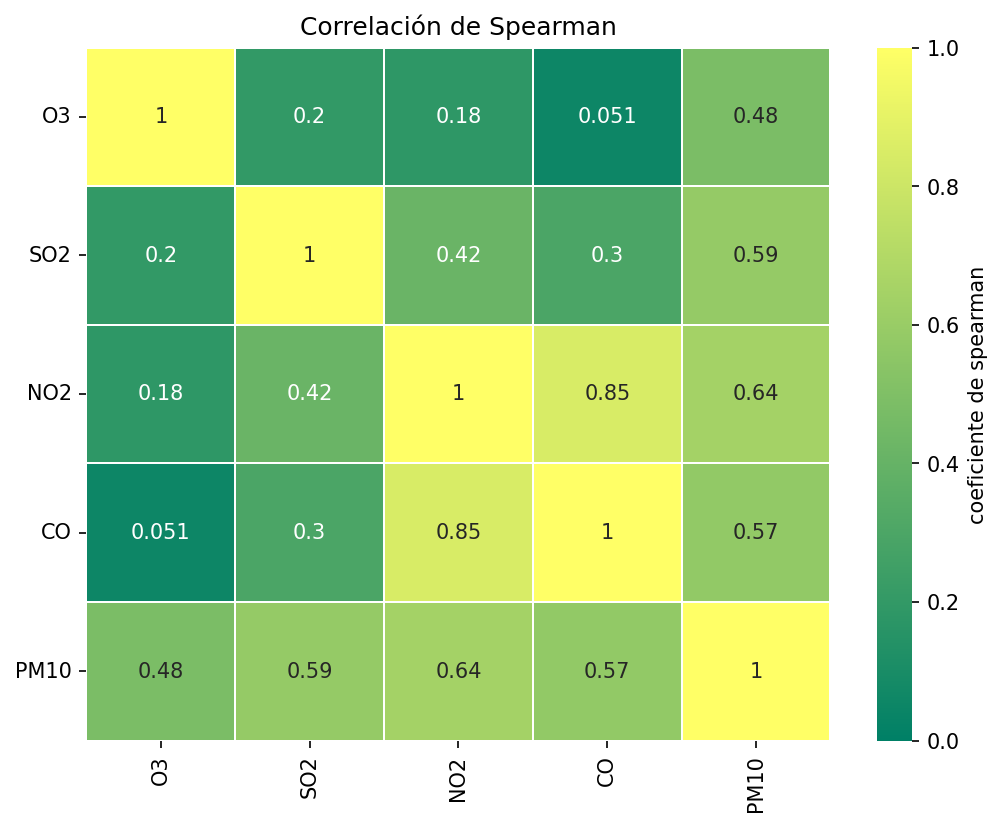

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6), dpi=150)

sns.heatmap(corr_spearman,
            annot=True,
            cmap='summer',
            linewidths=0.2,
            cbar_kws={'label': 'coeficiente de spearman'},
            vmin=0, vmax=1, center=.5
            )
plt.title('Correlación de Spearman')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [ ]:
#para hacer 2 gráficas en el mismo
cols = df.select_dtypes('number').columns
pear = df[cols].corr(method='pearson')
spear = df[cols].corr(method='spearman')

fig.plt
